In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [7]:
# Load base data
df = pd.read_csv('../data_processed/data_clean.csv')
print(f"Base data shape: {df.shape}")

# Try to load computed features
features_loaded = {}
feature_files = [
    '../features/lexical_complexity.csv',
    '../features/discourse_markers.csv',
    '../features/sentiment_emotion.csv',
    '../features/token_pos_counts.csv'
]

for f in feature_files:
    fp = Path(f)
    if fp.exists():
        try:
            features_loaded[f.split('/')[-1]] = pd.read_csv(fp)
            print(f"Loaded {f}")
        except Exception as e:
            print(f"Could not load {f}: {e}")

# Merge all features into one dataframe if available
if features_loaded:
    merged = df.copy()
    for fname, fdf in features_loaded.items():
        if '_id' in merged.columns and '_id' in fdf.columns:
            merged = merged.merge(fdf, on='_id', how='left')
    print(f"\nMerged feature dataframe shape: {merged.shape}")
    print(f"Columns: {merged.columns.tolist()}")

Base data shape: (3682, 3)
Loaded ../features/lexical_complexity.csv
Loaded ../features/discourse_markers.csv
Loaded ../features/sentiment_emotion.csv
Loaded ../features/token_pos_counts.csv

Merged feature dataframe shape: (9608, 30)
Columns: ['_id', 'text', 'conspiracy', 'ttr', 'hapax_ratio', 'avg_word_len', 'shannon_entropy', 'hedge_count', 'certainty_count', 'discourse_count', 'passive_count', 'neg', 'neu', 'pos', 'compound', 'emotion_fear', 'emotion_anger', 'emotion_anticipation', 'emotion_trust', 'emotion_surprise', 'emotion_sadness', 'emotion_joy', 'emotion_disgust', 'n_tokens', 'n_sentences', 'n_nouns', 'n_verbs', 'n_adjs', 'n_advs', 'n_pronouns']


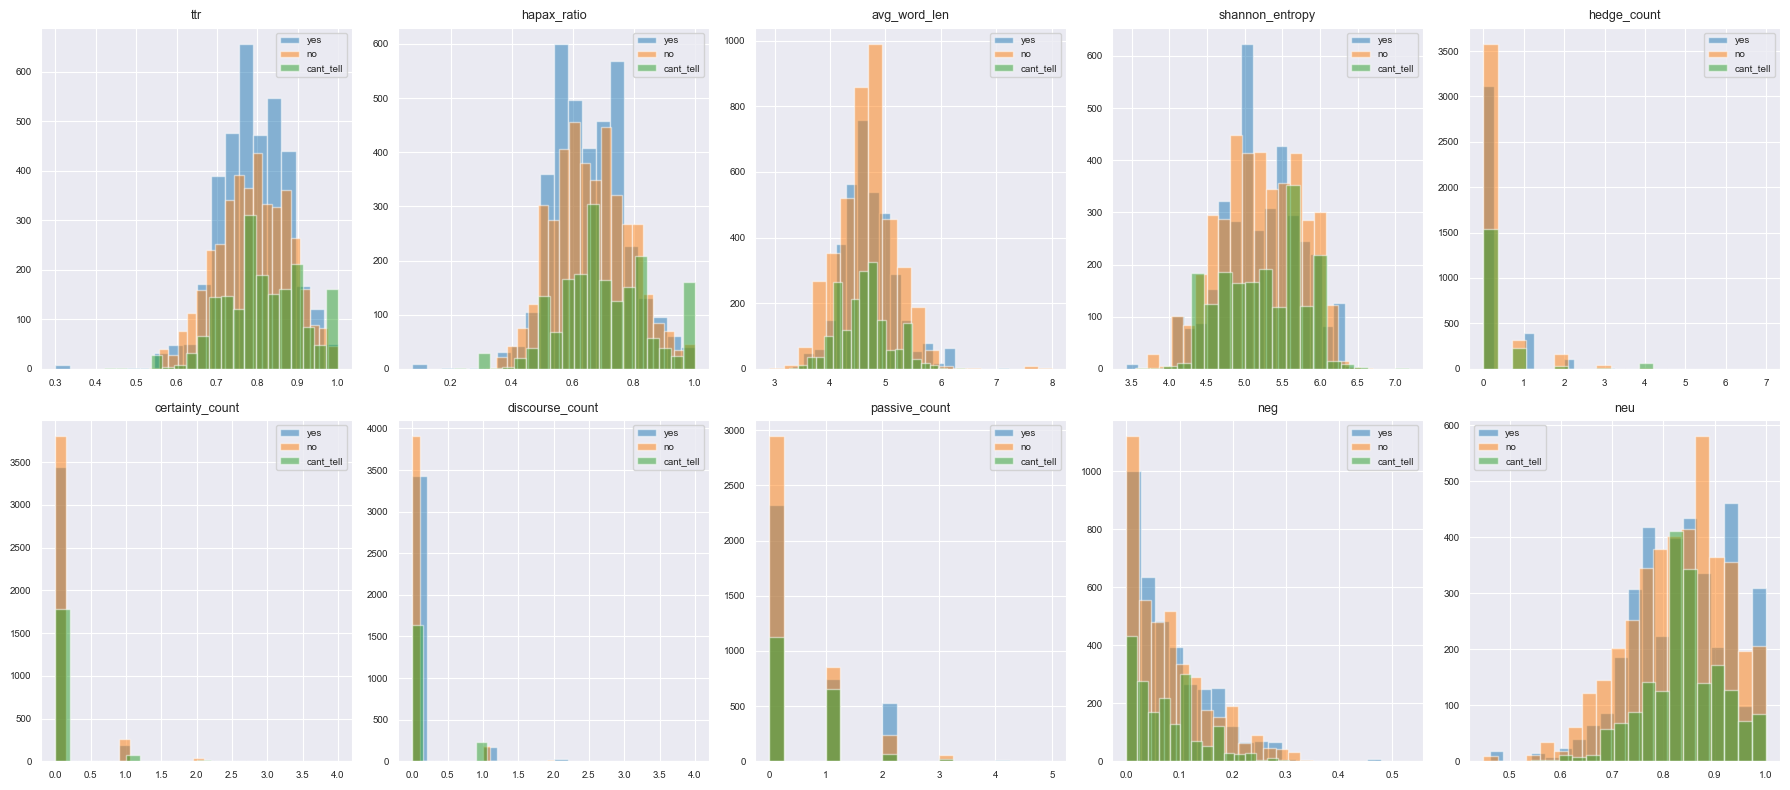


Feature summary statistics by label:
               ttr                                                    \
             count      mean       std       min       25%       50%   
conspiracy                                                             
cant_tell   1871.0  0.816976  0.101298  0.420000  0.748626  0.807692   
no          4102.0  0.790289  0.089393  0.532374  0.727273  0.791667   
yes         3635.0  0.791041  0.085283  0.300000  0.735294  0.787500   

                          hapax_ratio            ... shannon_entropy  \
                 75%  max       count      mean  ...             75%   
conspiracy                                       ...                   
cant_tell   0.891892  1.0      1871.0  0.703020  ...        5.681891   
no          0.857143  1.0      4102.0  0.661247  ...        5.638811   
yes         0.851852  1.0      3635.0  0.657516  ...        5.600516   

                     hedge_count                                               
                

In [8]:
# Feature distributions by label (if features are available)
if 'merged' in locals():
    numeric_cols = merged.select_dtypes(include=[float, int]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in ['_id']][:10]  # First 10 numeric features
    
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        if i < len(axes):
            for label in ['yes', 'no', 'cant_tell']:
                subset = merged[merged['conspiracy'] == label][col].dropna()
                if len(subset) > 0:
                    axes[i].hist(subset, bins=20, alpha=0.5, label=label)
            axes[i].set_title(col, fontsize=9)
            axes[i].legend(fontsize=7)
            axes[i].tick_params(labelsize=7)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\nFeature summary statistics by label:")
    print(merged.groupby('conspiracy')[numeric_cols[:5]].describe())

Top 20 features by SHAP importance:
       feature  importance
0    url_count    0.008464
1  email_count    0.008464


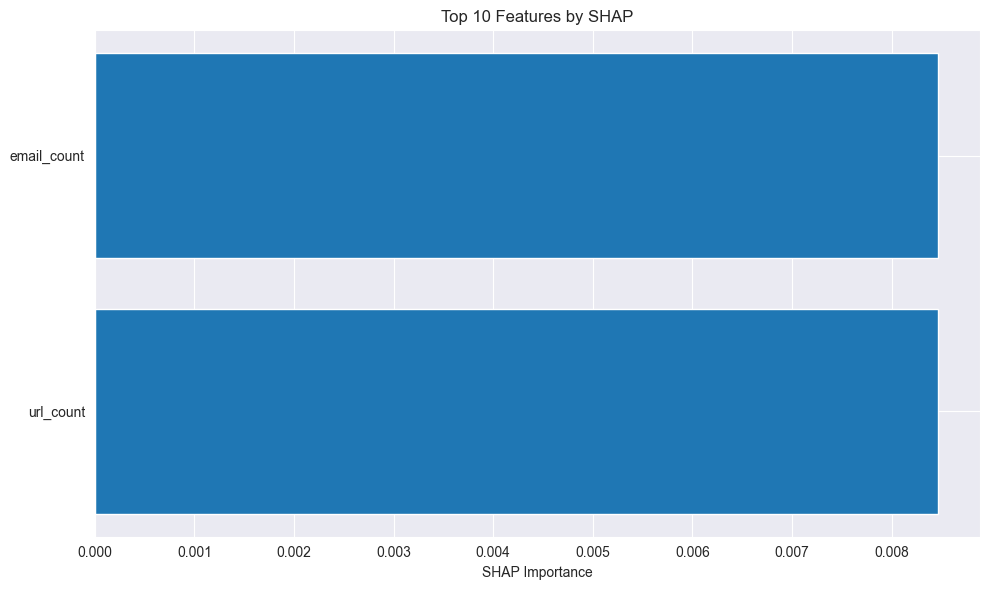

In [13]:
# Load SHAP top features if available
shap_path = Path('../shap_top20.csv')
if shap_path.exists():
    shap_df = pd.read_csv(shap_path)
    print("Top 20 features by SHAP importance:")
    print(shap_df)
    
    plt.figure(figsize=(10, 6))
    plt.barh(shap_df['feature'][:10], shap_df['importance'][:10])
    plt.xlabel('SHAP Importance')
    plt.title('Top 10 Features by SHAP')
    plt.tight_layout()
    plt.show()
else:
    print("SHAP top 20 file not found; features may not have been computed yet.")

In [14]:
# Load topic models if available
lda_path = Path('../topics/lda_topics_12.csv')
if lda_path.exists():
    lda_df = pd.read_csv(lda_path)
    print("Top LDA Topics (k=12):")
    print(lda_df.head(10))
else:
    print("LDA topics not found; topic modeling may not have run yet.")

bertopic_path = Path('../topics/bertopic_topics.csv')
if bertopic_path.exists():
    bertopic_df = pd.read_csv(bertopic_path)
    print("\nBERTopic Topics:")
    print(bertopic_df.head(10))
else:
    print("BERTopic topics not found; BERTopic may not have run yet.")

LDA topics not found; topic modeling may not have run yet.
BERTopic topics not found; BERTopic may not have run yet.


# Feature Analysis

Interactive exploration of computed features, distributions, and predictive importance.